<a href="https://colab.research.google.com/github/gkchandu/retail-sales-analytics-project/blob/main/03_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## What is EDA, and How Is This Deeper Than Earlier Analysis?

**EDA (Exploratory Data Analysis)** is the process of examining a dataset using
statistics and visualizations to understand its structure, patterns, and
relationships — before drawing conclusions or building further models.

Earlier stages of this project already involved a form of EDA — cleaning the
data, visualizing Sales by Category, and spotting the Discount-Profit relationship
visually during data cleaning and predictive modeling. This stage goes deeper by
**quantifying** those relationships with actual statistics, rather than relying
on visual impressions alone:

- Instead of just seeing that Technology "looks" highest in a bar chart, this
stage measures exact correlation coefficients between every numeric variable.
- Instead of eyeballing skew in a histogram, this stage calculates a precise
skewness value.
- Instead of comparing categories with a single bar chart, this stage compares
**mean vs median** to reveal when averages are being distorted by outliers.

In short: earlier analysis showed *that* patterns exist. This stage proves
*how strong* those patterns are, using statistical measures like correlation,
skewness, and grouped statistical comparisons.

In [ ]:
# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Retail_Sales_Analytics_Project/Sample - Superstore.csv', encoding='latin1')

# Convert Order Date to datetime (needed for later steps)
df['Order Date'] = pd.to_datetime(df['Order Date'])

df.head()

Mounted at /content/drive


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Step 1: Statistical Summary

In [ ]:
# Descriptive statistics for key numeric columns
df[['Sales', 'Profit', 'Discount', 'Quantity']].describe()

,Sales,Profit,Discount,Quantity
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,0.156203,3.789574
std,623.245101,234.260108,0.206452,2.225110
min,0.444000,-6599.978000,0.000000,1.000000
25%,17.280000,1.728750,0.000000,2.000000
50%,54.490000,8.666500,0.200000,3.000000
75%,209.940000,29.364000,0.200000,5.000000
max,22638.480000,8399.976000,0.800000,14.000000


## Step 2 & 3: Correlation Matrix and Heatmap

             Sales    Profit  Discount  Quantity
Sales     1.000000  0.479064 -0.028190  0.200795
Profit    0.479064  1.000000 -0.219487  0.066253
Discount -0.028190 -0.219487  1.000000  0.008623
Quantity  0.200795  0.066253  0.008623  1.000000


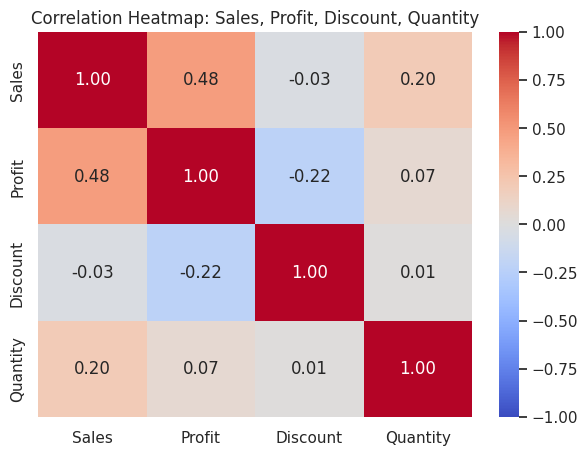

In [ ]:
# Compute correlation matrix between key numeric variables
corr_matrix = df[['Sales', 'Profit', 'Discount', 'Quantity']].corr()
print(corr_matrix)

# Visualize as a heatmap
plt.figure(figsize=(7,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Sales, Profit, Discount, Quantity')
plt.show()

## Step 4: Identifying Key Influencing Factors

In [ ]:
# Extract and sort correlations specifically with Profit and Sales
profit_corr = corr_matrix['Profit'].drop('Profit').sort_values(ascending=False)
sales_corr = corr_matrix['Sales'].drop('Sales').sort_values(ascending=False)

print("Correlation with Profit:\n", profit_corr)
print("\nCorrelation with Sales:\n", sales_corr)

Correlation with Profit:
 Sales       0.479064
Quantity    0.066253
Discount   -0.219487
Name: Profit, dtype: float64

Correlation with Sales:
 Profit      0.479064
Quantity    0.200795
Discount   -0.028190
Name: Sales, dtype: float64


## Step 5: Category-Level Statistical Comparison

In [ ]:
# Mean and median Profit/Sales by Category
category_stats = df.groupby('Category')[['Sales', 'Profit']].agg(['mean', 'median']).round(2)
print(category_stats)

# Mean and median Profit/Sales by Region
region_stats = df.groupby('Region')[['Sales', 'Profit']].agg(['mean', 'median']).round(2)
print(region_stats)

                  Sales         Profit       
                   mean  median   mean median
Category                                     
Furniture        349.83  182.22   8.70   7.77
Office Supplies  119.32   27.42  20.33   6.88
Technology       452.71  166.16  78.75  25.02
          Sales        Profit       
           mean median   mean median
Region                              
Central  215.77  45.98  17.09   5.18
East     238.34  54.90  32.14   8.17
South    241.80  54.59  28.86   9.07
West     226.49  60.84  33.85  11.17


## Step 6: Pivot Table - Category x Region

In [ ]:
# Average Sales by Category and Region combined
pivot_sales = pd.pivot_table(df, values='Sales', index='Category', columns='Region', aggfunc='mean').round(2)
pivot_sales

Region,Central,East,South,West
Category,,,,
Furniture,340.53,346.57,353.31,357.30
Office Supplies,117.46,120.04,126.28,116.42
Technology,405.75,495.28,507.75,420.69


## Step 7: Skewness Check

Sales skewness: 12.97
Profit skewness: 7.56


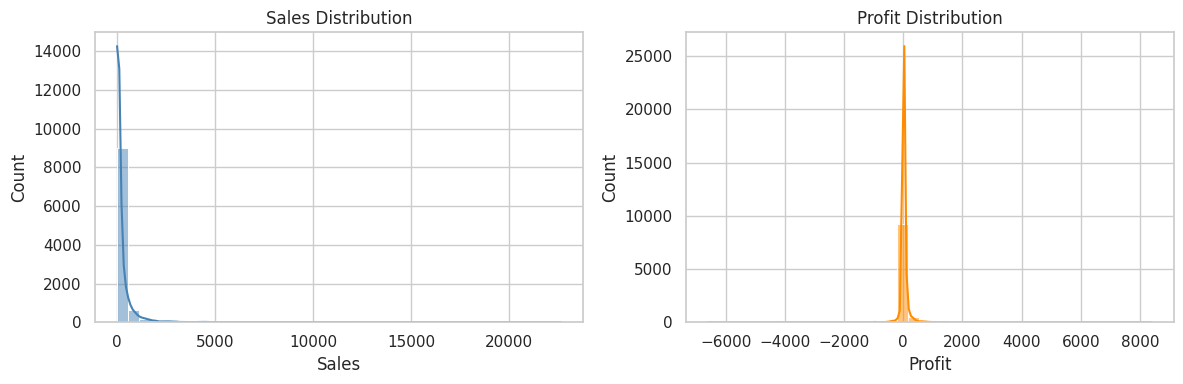

In [ ]:
# Calculate skewness for Sales and Profit
sales_skew = df['Sales'].skew()
profit_skew = df['Profit'].skew()
print(f"Sales skewness: {sales_skew:.2f}")
print(f"Profit skewness: {profit_skew:.2f}")

# Visualize the skew
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['Sales'], bins=40, color='steelblue', kde=True, ax=axes[0])
axes[0].set_title('Sales Distribution')
sns.histplot(df['Profit'], bins=40, color='darkorange', kde=True, ax=axes[1])
axes[1].set_title('Profit Distribution')
plt.tight_layout()
plt.show()

## Step 8: Top and Bottom Performers

In [ ]:
# Average profit by Sub-Category, sorted
subcat_profit = df.groupby('Sub-Category')['Profit'].mean().sort_values(ascending=False).round(2)

print("Top 5 Sub-Categories by Average Profit:")
print(subcat_profit.head(5))

print("\nBottom 5 Sub-Categories by Average Profit:")
print(subcat_profit.tail(5))

Top 5 Sub-Categories by Average Profit:
Sub-Category
Copiers        817.91
Accessories     54.11
Phones          50.07
Chairs          43.10
Appliances      38.92
Name: Profit, dtype: float64

Bottom 5 Sub-Categories by Average Profit:
Sub-Category
Art           8.20
Fasteners     4.38
Supplies     -6.26
Bookcases   -15.23
Tables      -55.57
Name: Profit, dtype: float64


## Step 9: Visualizing the Strongest Correlation

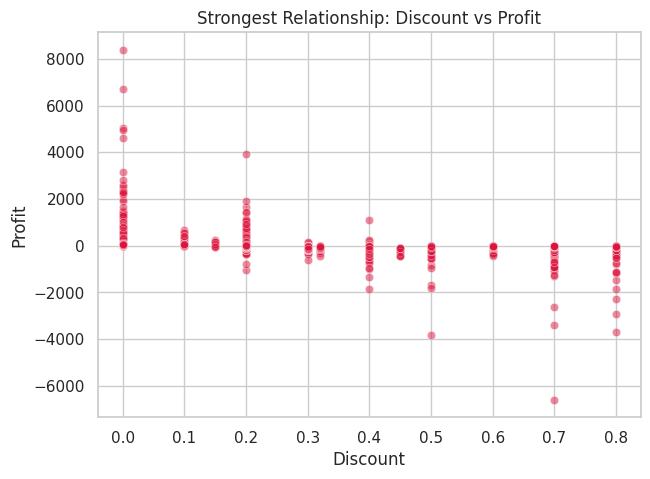

In [ ]:
# Scatter plot for the strongest correlated pair found earlier
# (Update the x variable below based on what Step 4's output actually shows)
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5, color='crimson')
plt.title('Strongest Relationship: Discount vs Profit')
plt.show()

## Conclusion: Exploratory Data Analysis

**Statistical Summary:** Sales and Profit both show high variability relative to
their averages — Sales has a mean of **229.86** but a standard deviation of
**623.25**, and Profit's minimum value (**-6,599.98**) sits far below its 75th
percentile (**29.36**). This confirms what Week 1's boxplot showed visually: a small
number of extreme losses are pulling the numbers wide, rather than typical orders
being consistently volatile.

**Correlation Findings:** Sales and Profit have a moderate positive correlation
(**0.48**) — more sales generally means more profit, though not perfectly. Discount
has a moderate negative correlation with Profit (**-0.22**), confirming Week 2's
visual finding that heavier discounting tends to erode profit. Quantity has only a
weak relationship with both Sales (**0.20**) and Profit (**0.07**) — how many units
are sold matters far less than the price/discount applied.

**Category & Region Comparison:** A clear gap exists between each category's **mean**
and **median** profit — for example, Technology's mean profit (**78.75**) is roughly
**3x** its median (**25.02**). This means the "average" profit figure is misleading
on its own: a handful of highly profitable orders are inflating the mean, while most
individual orders earn far less. Office Supplies shows the same pattern (mean
**20.33** vs median **6.88**). Regionally, the West leads in median profit (**11.17**),
while Central lags behind (**5.18**).

**Pivot Table (Category × Region):** Technology consistently earns the highest average
Sales across all four regions, peaking in the **South** (**507.75**), while Office
Supplies stays consistently lowest across every region — confirming the category
gap seen in Week 1 holds true regardless of region.

**Skewness:** Both Sales (**12.97**) and Profit (**7.56**) are extremely
right-skewed — well above the ~1.0 threshold typically considered "highly skewed."
This numerically confirms the long-tailed distributions visible in the histograms,
and explains why Week 2's regression models struggled to predict Sales precisely:
a small number of very large orders sit far outside the typical range most models
learn from.

**Top & Bottom Performers:** **Copiers** is an outsized outlier — its average profit
(**817.91**) is nearly **15x** higher than the next best Sub-Category, Accessories
(**54.11**). At the other end, **Tables** average **-55.57** profit — meaning Tables
lose money on average, not just occasionally. **Bookcases** (**-15.23**) and
**Supplies** (**-6.26**) are also net loss-making on average.

**Strongest Relationship (Visualized):** The Discount vs Profit scatter plot makes
the -0.22 correlation concrete: profit is almost entirely positive at 0% discount,
but flips increasingly negative as discount rises past **50-70%**, with the most
extreme losses occurring at the highest discount levels.

### Overall Takeaway
The data reveals two consistent business risks: **heavy discounting** and
**specific underperforming Sub-Categories** (Tables, Bookcases, Supplies) are the
biggest drags on profitability, while a small number of high-value products
(like Copiers) and categories (Technology) disproportionately drive overall
profit. This sets up Week 4's real-world application well — any business
recommendation should focus on **discount policy** and **Sub-Category-level
strategy**, rather than broad category or regional changes alone.

## Worth Noting

- **Mean profit is consistently 2-3x higher than median profit** across every
category and region — a repeated pattern, not a one-off. Any report using
"average profit" alone would overstate typical order performance.

- **Discount's effect on Profit isn't linear** — profit stays roughly stable
up to ~20% discount, then drops sharply beyond 50%. A specific "safe" discount
threshold likely exists, rather than discount being a simple straight-line risk.

## Future Enhancements

- Investigate **Copiers and Tables** individually at the order level to understand
what's driving their extreme performance in either direction.
- Identify a specific **discount threshold** where profit reliably turns negative,
using more granular discount bands.